In [1]:
# imports
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, Dataset
import torch.nn as nn
import torch.optim as optim
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from collections import Counter
from tqdm import tqdm
import sklearn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# constants
DATASET_PATH = "/kaggle/input/datasets/unclesamulus/blood-cells-image-dataset/bloodcells_dataset"
KEEP_CLASSES = ['basophil', 'eosinophil', 'lymphocyte', 'monocyte', 'neutrophil']
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
NUM_CLASSES = 5

In [3]:
# augmentation
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1,contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# dataset
class CustomLeukocyteDataset(Dataset):
    def __init__(self, subset, transform, label_mapping):
        self.subset = subset
        self.transform = transform
        self.label_mapping = label_mapping

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        y = self.label_mapping[y]
        return x, y

In [5]:
# imagefolder
full_dataset = datasets.ImageFolder(DATASET_PATH)

keep_indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if full_dataset.classes[label] in KEEP_CLASSES
]

In [6]:
# train-val-test
all_names = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in keep_indices]
class_counts = Counter(all_names)
print(class_counts)

np.random.seed(42)
shuffled_indices = np.random.permutation(keep_indices)

total = len(keep_indices)
train_size = int(0.7 * total)
val_size   = int(0.2 * total)
test_size  = total - train_size - val_size

train_indices = shuffled_indices[:train_size]
val_indices   = shuffled_indices[train_size:train_size + val_size]
test_indices  = shuffled_indices[train_size + val_size:]

Counter({'neutrophil': 3329, 'eosinophil': 3117, 'monocyte': 1420, 'basophil': 1218, 'lymphocyte': 1214})


In [7]:
train_classes = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in train_indices]
print("⚖️ Баланс в Train (70%):", Counter(train_classes))

val_classes = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in val_indices]
print("⚖️ Баланс в Val (20%):  ", Counter(val_classes))

test_classes = [full_dataset.classes[full_dataset.samples[idx][1]] for idx in test_indices]
print("⚖️ Баланс в Test (10%): ", Counter(test_classes))

⚖️ Баланс в Train (70%): Counter({'neutrophil': 2290, 'eosinophil': 2215, 'monocyte': 985, 'basophil': 870, 'lymphocyte': 848})
⚖️ Баланс в Val (20%):   Counter({'neutrophil': 705, 'eosinophil': 605, 'monocyte': 279, 'lymphocyte': 240, 'basophil': 230})
⚖️ Баланс в Test (10%):  Counter({'neutrophil': 334, 'eosinophil': 297, 'monocyte': 156, 'lymphocyte': 126, 'basophil': 118})


In [8]:
# new numbers, subsets
label_mapping={}
for new_idx, class_name in enumerate(KEEP_CLASSES):
  old_idx=full_dataset.class_to_idx[class_name]
  label_mapping[old_idx]=new_idx

train_subset=Subset(full_dataset, train_indices)
val_subset=Subset(full_dataset, val_indices)
test_subset=Subset(full_dataset, test_indices)
print(len(train_subset))
print(len(val_subset))
print(len(test_subset))

7208
2059
1031


In [9]:
# dataset train-val-test
train_dataset = CustomLeukocyteDataset(
    subset=train_subset,
    transform=train_transform,
    label_mapping=label_mapping
    )
val_dataset   = CustomLeukocyteDataset(
    subset=val_subset,
    transform=val_transform,
    label_mapping=label_mapping
    )
test_dataset  = CustomLeukocyteDataset(
    subset=test_subset,
    transform=test_transform,
    label_mapping=label_mapping
    )
x, y = train_dataset[0]
print(type(x))
print(x.shape)
print(y)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
2


In [10]:
# dataloader
train_loader = DataLoader(
    dataset = train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    dataset = val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(labels[:10])
print(label_mapping)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([1, 0, 1, 4, 0, 0, 1, 3, 1, 4])
{0: 0, 1: 1, 4: 2, 5: 3, 6: 4}


In [11]:
# convnext-tiny
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
else:
    device = "cpu"

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(weights=weights)

num_features = model.classifier[2].in_features

model.classifier[2] = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print(f"Устройство: {device}")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 182MB/s] 


Устройство: cuda
Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=5, bias=True)
)


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Criterion:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Criterion: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7b377907b380>


In [13]:
# initialize tracking variables
best_val_loss = float("inf")
best_model_path = "convnext_tiny_leukocytes_best.pth"

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [14]:
for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

Epoch 1/20: 100%|██████████| 226/226 [02:08<00:00,  1.76it/s]


Epoch [1/20] | Train Loss: 0.1276 | Train Acc: 0.9621 | Val Loss: 0.0223 | Val Acc: 0.9932 | LR: 0.000100


Epoch 2/20: 100%|██████████| 226/226 [02:14<00:00,  1.68it/s]


Epoch [2/20] | Train Loss: 0.0321 | Train Acc: 0.9911 | Val Loss: 0.0349 | Val Acc: 0.9883 | LR: 0.000100


Epoch 3/20: 100%|██████████| 226/226 [02:13<00:00,  1.69it/s]


...

Epoch [18/20] | Train Loss: 0.0007 | Train Acc: 0.9997 | Val Loss: 0.0121 | Val Acc: 0.9981 | LR: 0.000050


Epoch 19/20: 100%|██████████| 226/226 [02:13<00:00,  1.69it/s]


Epoch [19/20] | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.0132 | Val Acc: 0.9981 | LR: 0.000025


Epoch 20/20: 100%|██████████| 226/226 [02:13<00:00,  1.70it/s]


Epoch [20/20] | Train Loss: 0.0005 | Train Acc: 0.9999 | Val Loss: 0.0127 | Val Acc: 0.9981 | LR: 0.000025


In [15]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

print("Лучшая модель загружена")

Лучшая модель загружена


In [16]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=KEEP_CLASSES
    )
)

cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)

Test Accuracy: 0.997090203685742

Classification Report:
              precision    recall  f1-score   support

    basophil       1.00      1.00      1.00       118
  eosinophil       1.00      1.00      1.00       297
  lymphocyte       0.99      1.00      1.00       126
    monocyte       0.99      0.99      0.99       156
  neutrophil       1.00      1.00      1.00       334

    accuracy                           1.00      1031
   macro avg       1.00      1.00      1.00      1031
weighted avg       1.00      1.00      1.00      1031


Confusion Matrix:
[[118   0   0   0   0]
 [  0 297   0   0   0]
 [  0   0 126   0   0]
 [  0   0   1 154   1]
 [  0   0   0   1 333]]


<Figure size 800x800 with 0 Axes>

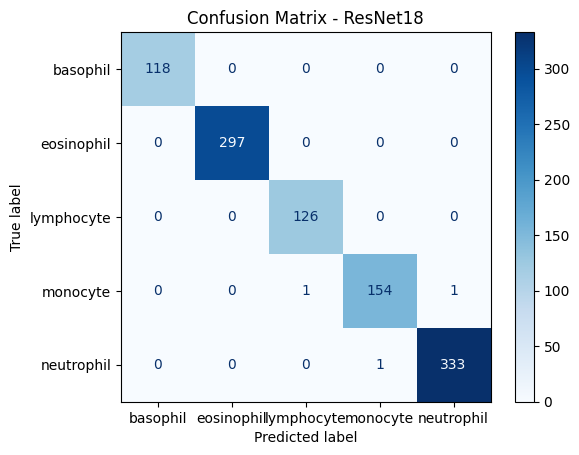

In [17]:
# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=KEEP_CLASSES
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - ResNet18")
plt.show()

In [18]:
misclassified = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i].cpu() != labels[i]:
                misclassified.append(
                    (
                        images[i].cpu(),
                        labels[i].item(),
                        preds[i].cpu().item()
                    )
                )

print("Количество ошибок:", len(misclassified))

Количество ошибок: 3


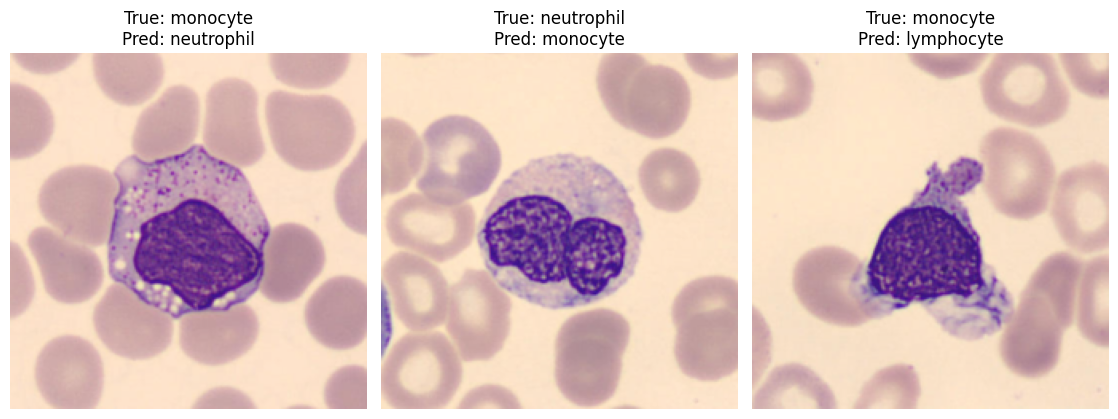

In [19]:
# visualizing misclassified images
num_show = min(7, len(misclassified))

plt.figure(figsize=(15, 10))

for i in range(num_show):

    image, true_label, pred_label = misclassified[i]

    image = image.permute(1, 2, 0).numpy()

    # денормализация ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = std * image + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {KEEP_CLASSES[true_label]}\nPred: {KEEP_CLASSES[pred_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

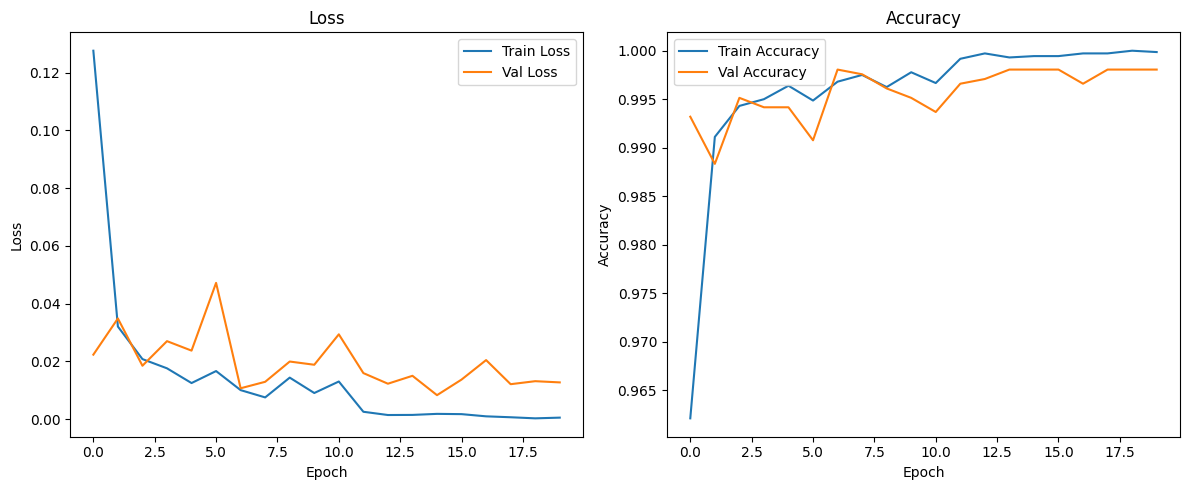

In [20]:
# plotting learning curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()

# test with other images

In [30]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

class_names = [
    'basophil',
    'eosinophil',
    'lymphocyte',
    'monocyte',
    'neutrophil'
]

def predict_folder(folder_path, threshold=0.7):

    model.eval()

    image_files = sorted(os.listdir(folder_path))

    for file_name in image_files:

        image_path = os.path.join(folder_path, file_name)

        try:
            image = Image.open(image_path).convert("RGB")
        except:
            continue

        # показываем изображение
        plt.figure(figsize=(5,5))
        plt.imshow(image)
        plt.title(file_name)
        plt.axis("off")
        plt.show()

        # preprocessing
        x = val_transform(image)
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(x)
            probs = F.softmax(outputs, dim=1)

        probs = probs.cpu().numpy()[0]

        predicted_idx = probs.argmax()

        predicted_class = class_names[predicted_idx]

        confidence = probs[predicted_idx]

        print("="*50)
        print("Image:", file_name)

        if confidence < threshold:
            print("Prediction: UNKNOWN")
            print(f"Most similar class: {predicted_class}")
        else:
            print(f"Prediction: {predicted_class}")

        print(f"Confidence: {confidence*100:.2f}%")

        print("\nProbabilities:")

        for cls, p in zip(class_names, probs):
            print(f"{cls:12s}: {p*100:.2f}%")

        # barplot
        plt.figure(figsize=(7,4))
        plt.bar(class_names, probs)
        plt.ylabel("Probability")
        plt.xticks(rotation=45)
        plt.show()

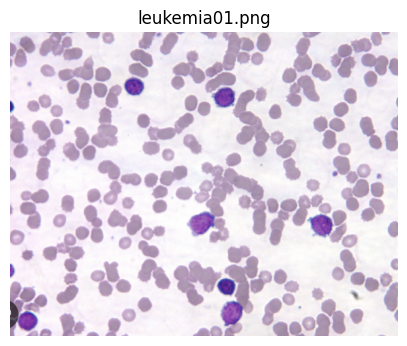

Image: leukemia01.png
Prediction: UNKNOWN
Most similar class: neutrophil
Confidence: 55.65%

Probabilities:
basophil    : 18.41%
eosinophil  : 8.67%
lymphocyte  : 4.85%
monocyte    : 12.43%
neutrophil  : 55.65%


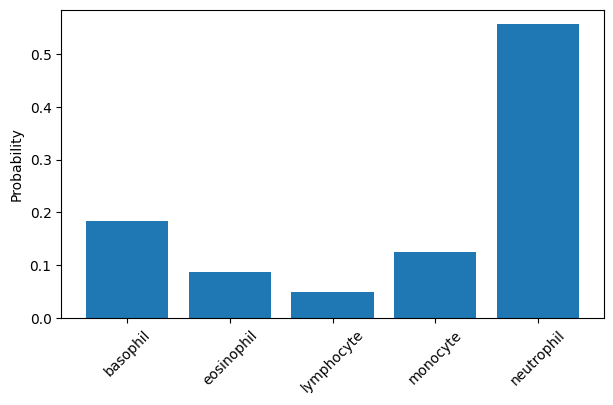

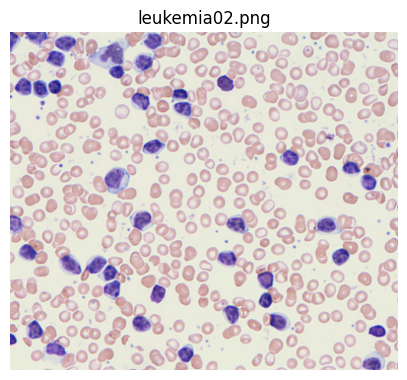

Image: leukemia02.png
Prediction: eosinophil
Confidence: 95.04%

Probabilities:
basophil    : 0.79%
eosinophil  : 95.04%
lymphocyte  : 0.41%
monocyte    : 0.58%
neutrophil  : 3.18%


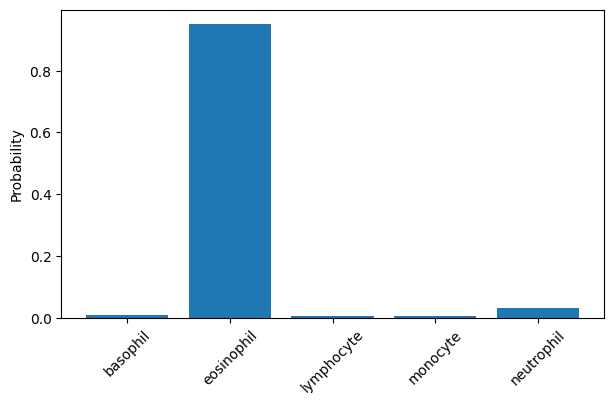

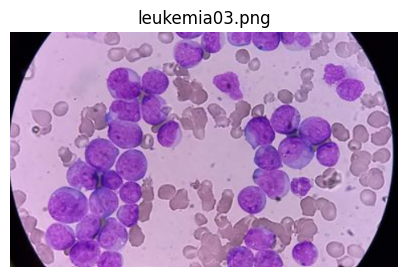

Image: leukemia03.png
Prediction: UNKNOWN
Most similar class: neutrophil
Confidence: 56.05%

Probabilities:
basophil    : 11.95%
eosinophil  : 6.70%
lymphocyte  : 0.41%
monocyte    : 24.89%
neutrophil  : 56.05%


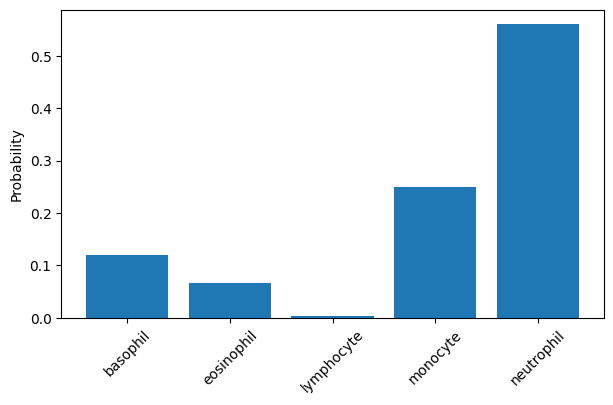

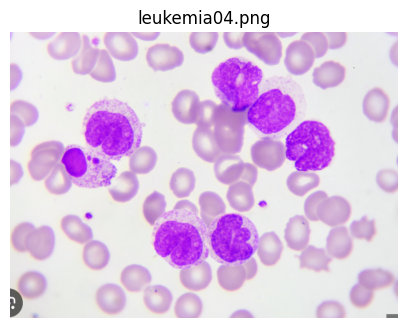

Image: leukemia04.png
Prediction: UNKNOWN
Most similar class: monocyte
Confidence: 41.51%

Probabilities:
basophil    : 3.94%
eosinophil  : 12.44%
lymphocyte  : 31.96%
monocyte    : 41.51%
neutrophil  : 10.15%


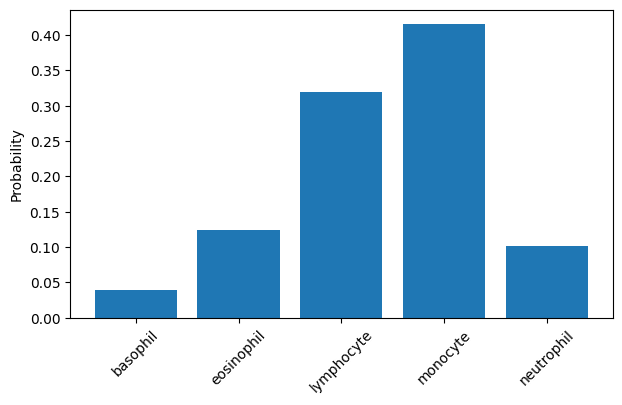

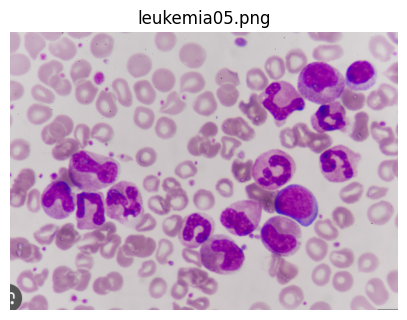

Image: leukemia05.png
Prediction: UNKNOWN
Most similar class: monocyte
Confidence: 32.19%

Probabilities:
basophil    : 17.65%
eosinophil  : 31.73%
lymphocyte  : 3.22%
monocyte    : 32.19%
neutrophil  : 15.20%


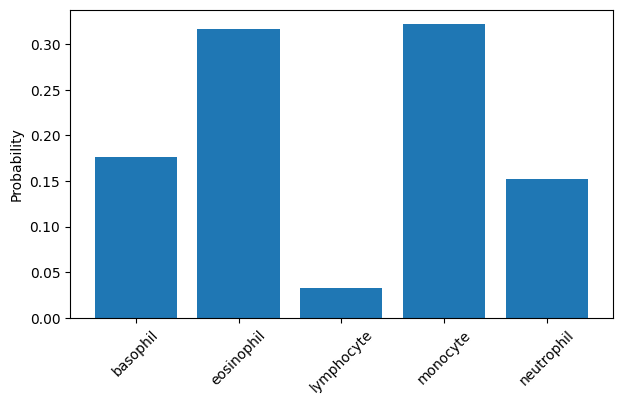

In [31]:
predict_folder(
"/kaggle/input/datasets/zarinaergasheva/test-images/test_images/leukemia_cells"
)

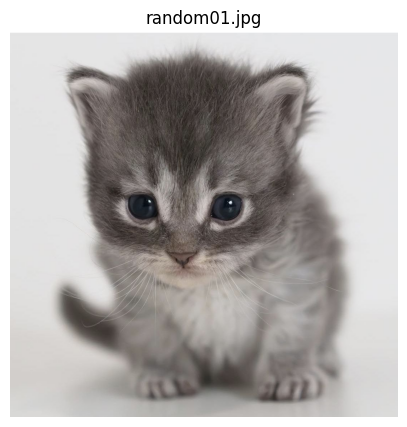

Image: random01.jpg
Prediction: UNKNOWN
Most similar class: monocyte
Confidence: 62.35%

Probabilities:
basophil    : 5.84%
eosinophil  : 3.28%
lymphocyte  : 1.37%
monocyte    : 62.35%
neutrophil  : 27.16%


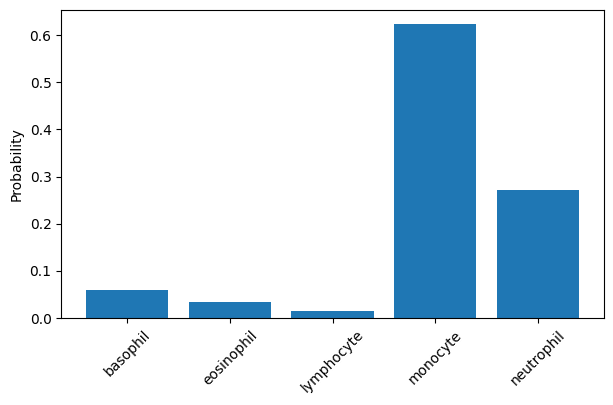

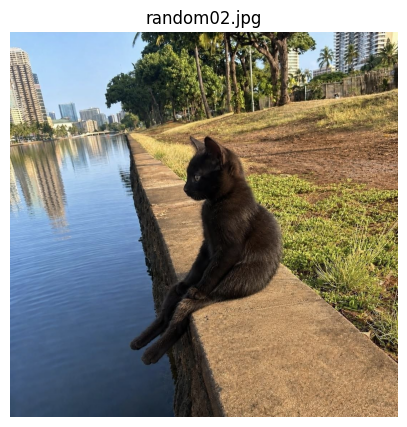

Image: random02.jpg
Prediction: neutrophil
Confidence: 93.12%

Probabilities:
basophil    : 0.65%
eosinophil  : 0.71%
lymphocyte  : 0.99%
monocyte    : 4.54%
neutrophil  : 93.12%


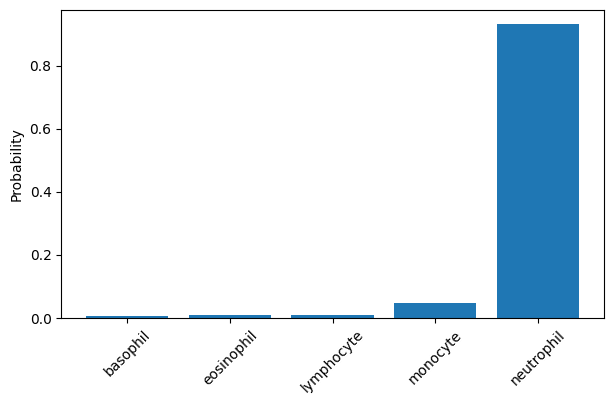

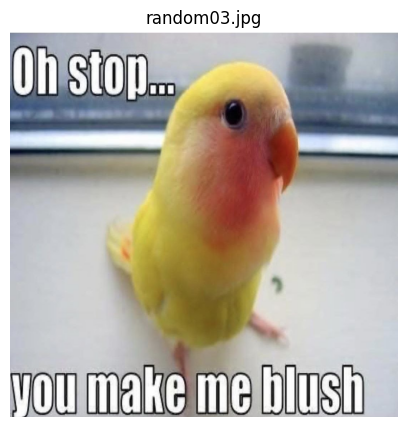

Image: random03.jpg
Prediction: UNKNOWN
Most similar class: monocyte
Confidence: 54.42%

Probabilities:
basophil    : 7.50%
eosinophil  : 35.38%
lymphocyte  : 0.61%
monocyte    : 54.42%
neutrophil  : 2.09%


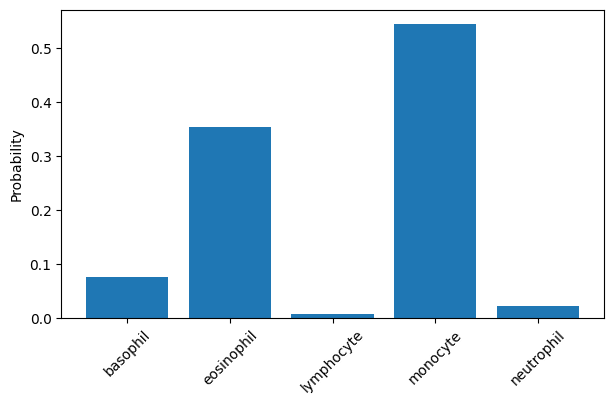

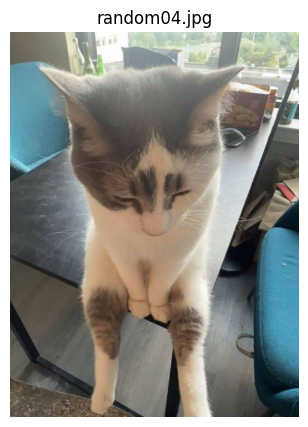

Image: random04.jpg
Prediction: UNKNOWN
Most similar class: monocyte
Confidence: 62.18%

Probabilities:
basophil    : 5.96%
eosinophil  : 15.73%
lymphocyte  : 3.07%
monocyte    : 62.18%
neutrophil  : 13.06%


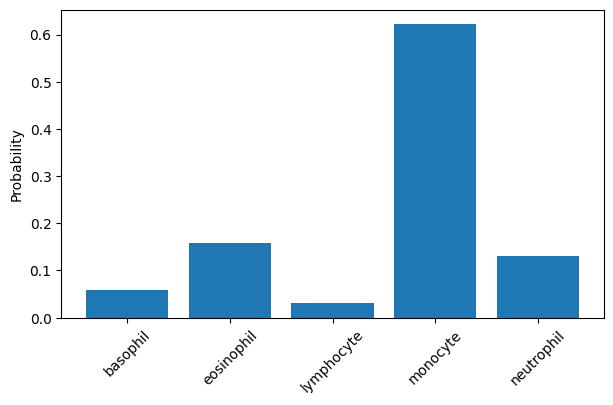

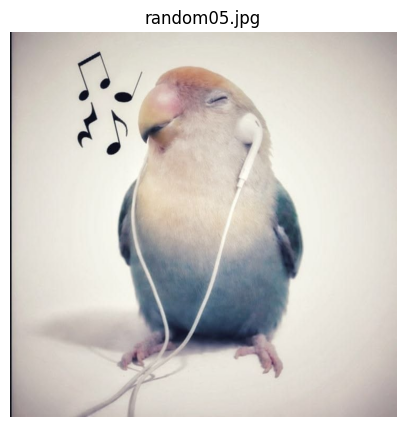

Image: random05.jpg
Prediction: eosinophil
Confidence: 81.96%

Probabilities:
basophil    : 5.62%
eosinophil  : 81.96%
lymphocyte  : 0.59%
monocyte    : 10.26%
neutrophil  : 1.57%


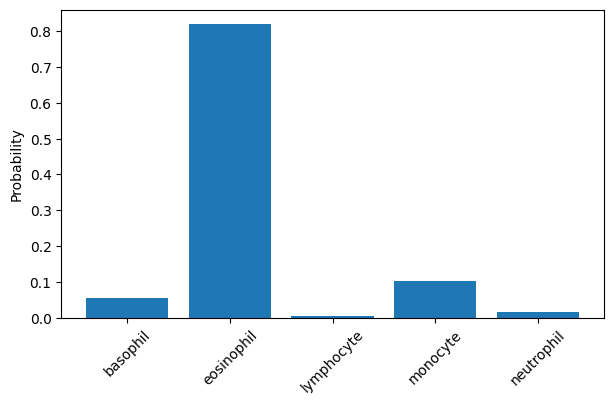

In [32]:
predict_folder(
"/kaggle/input/datasets/zarinaergasheva/test-images/test_images/random"
)

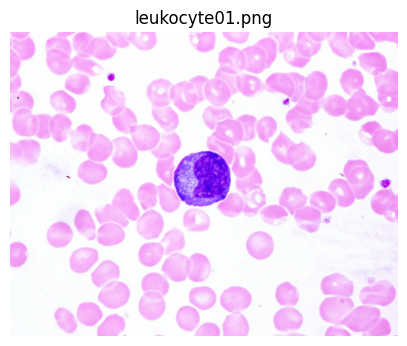

Image: leukocyte01.png
Prediction: eosinophil
Confidence: 96.98%

Probabilities:
basophil    : 0.21%
eosinophil  : 96.98%
lymphocyte  : 2.07%
monocyte    : 0.36%
neutrophil  : 0.38%


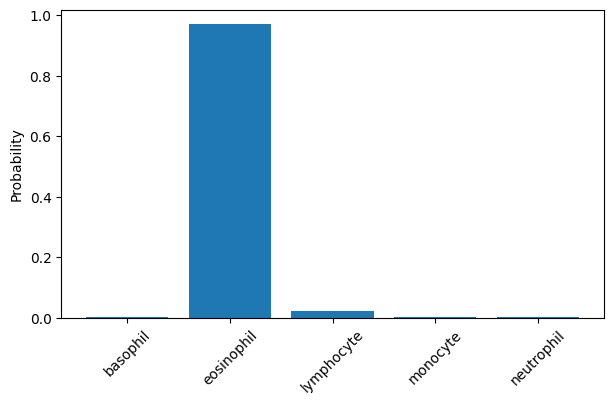

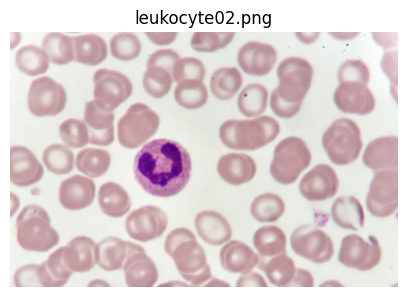

Image: leukocyte02.png
Prediction: neutrophil
Confidence: 91.93%

Probabilities:
basophil    : 1.95%
eosinophil  : 1.68%
lymphocyte  : 2.40%
monocyte    : 2.04%
neutrophil  : 91.93%


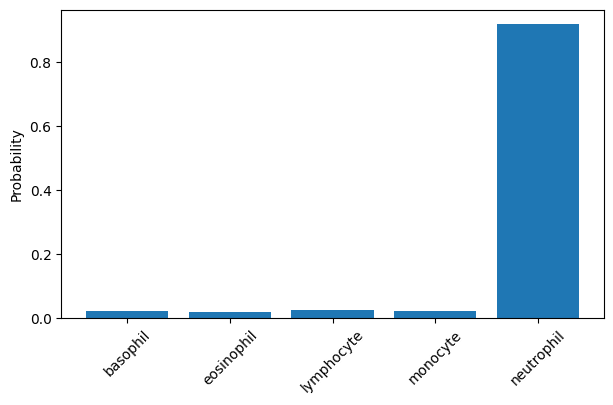

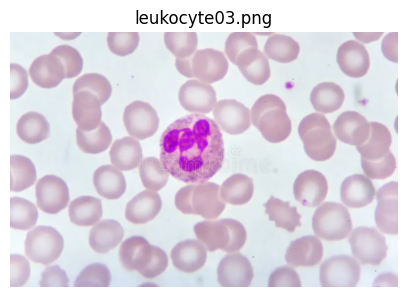

Image: leukocyte03.png
Prediction: eosinophil
Confidence: 72.39%

Probabilities:
basophil    : 2.05%
eosinophil  : 72.39%
lymphocyte  : 1.85%
monocyte    : 6.43%
neutrophil  : 17.27%


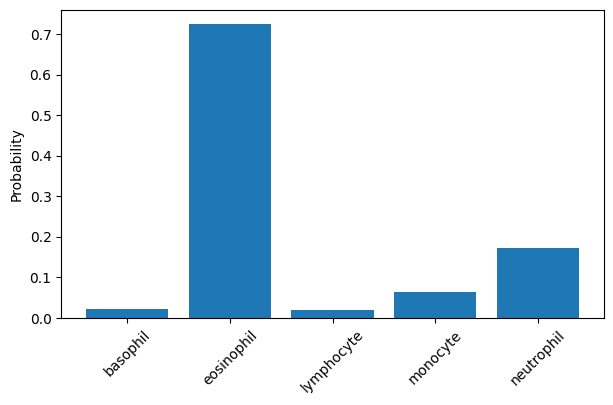

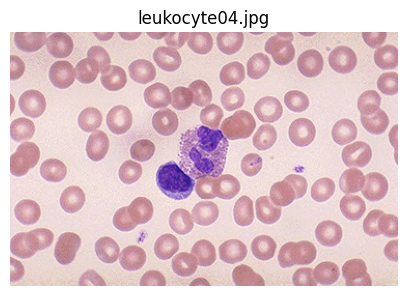

Image: leukocyte04.jpg
Prediction: eosinophil
Confidence: 99.45%

Probabilities:
basophil    : 0.07%
eosinophil  : 99.45%
lymphocyte  : 0.08%
monocyte    : 0.06%
neutrophil  : 0.34%


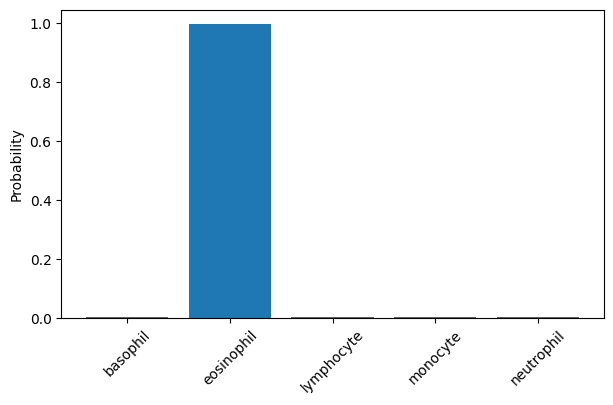

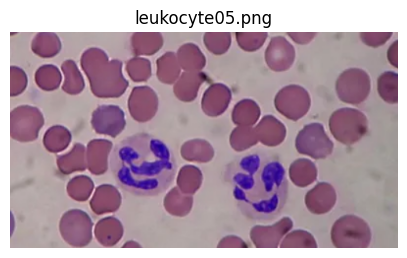

Image: leukocyte05.png
Prediction: UNKNOWN
Most similar class: monocyte
Confidence: 49.26%

Probabilities:
basophil    : 3.70%
eosinophil  : 7.29%
lymphocyte  : 1.20%
monocyte    : 49.26%
neutrophil  : 38.54%


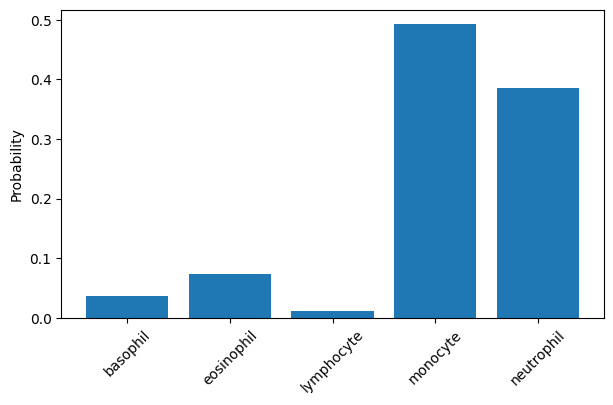

In [33]:
predict_folder(
"/kaggle/input/datasets/zarinaergasheva/test-images/test_images/single_cells"
)

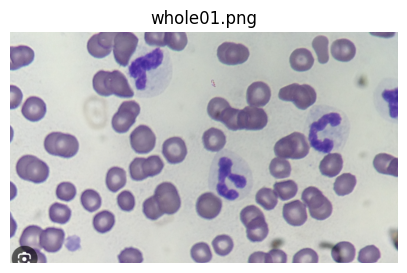

Image: whole01.png
Prediction: neutrophil
Confidence: 87.79%

Probabilities:
basophil    : 4.06%
eosinophil  : 0.91%
lymphocyte  : 1.26%
monocyte    : 5.99%
neutrophil  : 87.79%


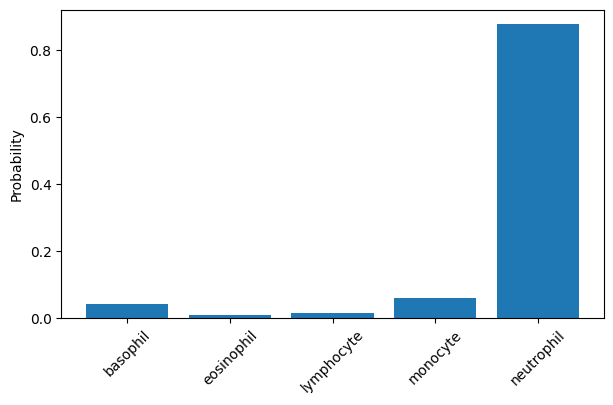

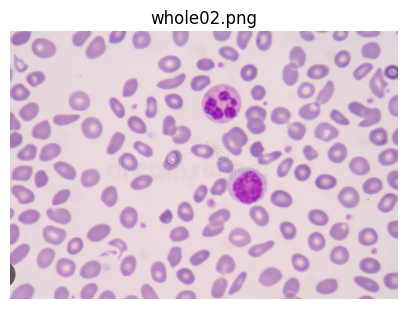

Image: whole02.png
Prediction: UNKNOWN
Most similar class: eosinophil
Confidence: 45.53%

Probabilities:
basophil    : 12.00%
eosinophil  : 45.53%
lymphocyte  : 26.67%
monocyte    : 11.37%
neutrophil  : 4.44%


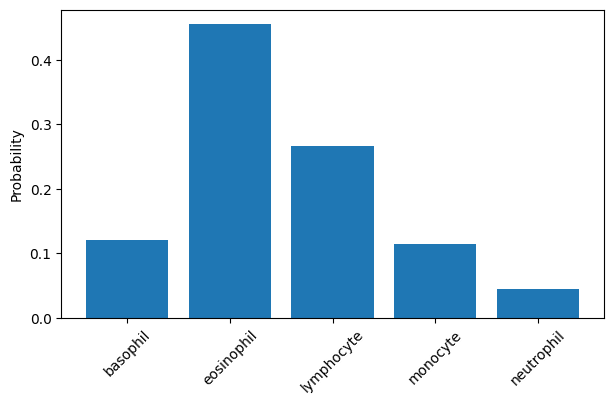

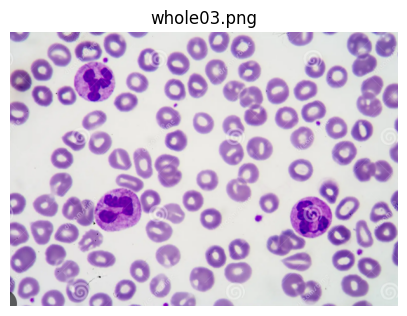

Image: whole03.png
Prediction: UNKNOWN
Most similar class: eosinophil
Confidence: 32.44%

Probabilities:
basophil    : 30.25%
eosinophil  : 32.44%
lymphocyte  : 17.63%
monocyte    : 4.41%
neutrophil  : 15.27%


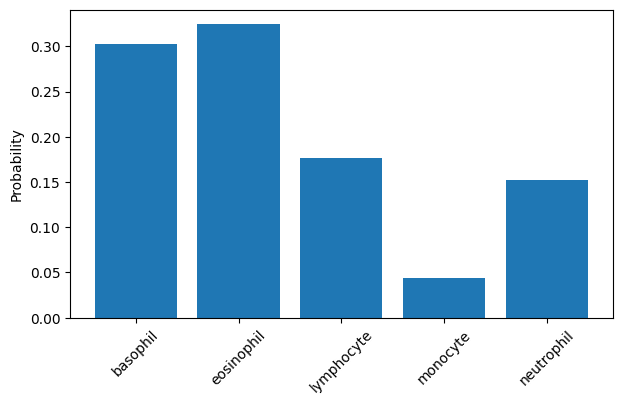

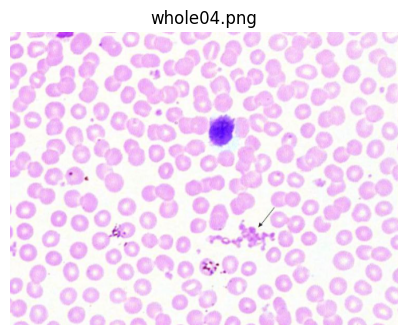

Image: whole04.png
Prediction: UNKNOWN
Most similar class: eosinophil
Confidence: 39.31%

Probabilities:
basophil    : 8.85%
eosinophil  : 39.31%
lymphocyte  : 8.26%
monocyte    : 7.94%
neutrophil  : 35.64%


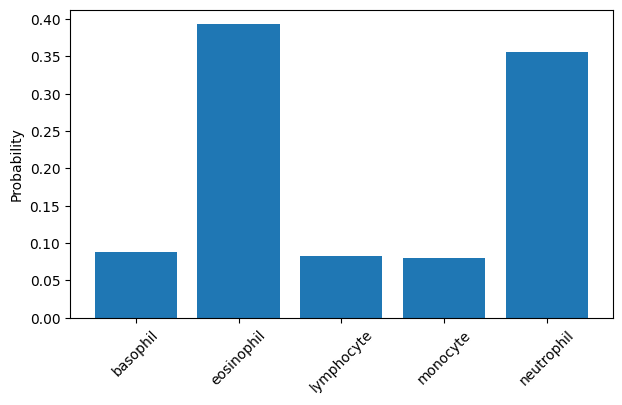

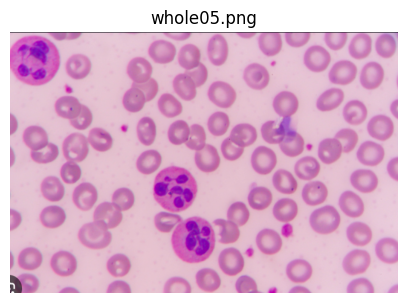

Image: whole05.png
Prediction: eosinophil
Confidence: 82.69%

Probabilities:
basophil    : 4.95%
eosinophil  : 82.69%
lymphocyte  : 4.07%
monocyte    : 2.79%
neutrophil  : 5.49%


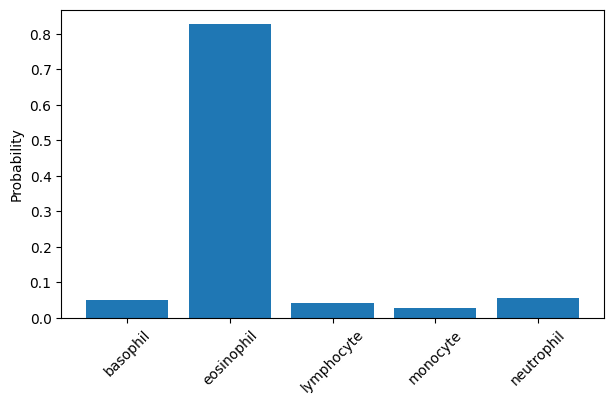

In [34]:
predict_folder(
"/kaggle/input/datasets/zarinaergasheva/test-images/test_images/whole_smears"
)